# Daisyworld: численность при разных параметрах

Для четырёх сочетаний рассчитываются независимые траектории длиной 1000 шагов.

## Параметрические прогоны

In [1]:
using DrWatson
@quickactivate "DaisyworldLab"
include(srcdir("experiment_tools.jl"))

summary_rows = NamedTuple[]
comparison = Figure(size=(1200, 900))
for (run, parameters) in enumerate(parameter_sets())
    model = create_world(; parameters...)
    trajectory = history_frame(model, 1000)
    save_history(trajectory, "daisyworld-count__param";
                 filename="trajectory-run-$(run).csv")
    push!(summary_rows, (
        run=run, max_age=parameters[:max_age], init_white=parameters[:init_white],
        final_black=last(trajectory.black), final_white=last(trajectory.white),
        peak_black=maximum(trajectory.black), peak_white=maximum(trajectory.white),
        extinction_step=extinction_time(trajectory),
        mean_regulation_error=mean(trajectory.regulation_error),
    ))
    ax = Axis(comparison[(run - 1) ÷ 2 + 1, (run - 1) % 2 + 1],
              title="Возраст $(parameters[:max_age]), белые $(parameters[:init_white])",
              xlabel="Шаг", ylabel="Число растений")
    lines!(ax, trajectory.time, trajectory.black; color=:black, label="Чёрные")
    lines!(ax, trajectory.time, trajectory.white; color=:orange, label="Белые")
    run == 1 && axislegend(ax; position=:rt)
end

## Итоговые показатели

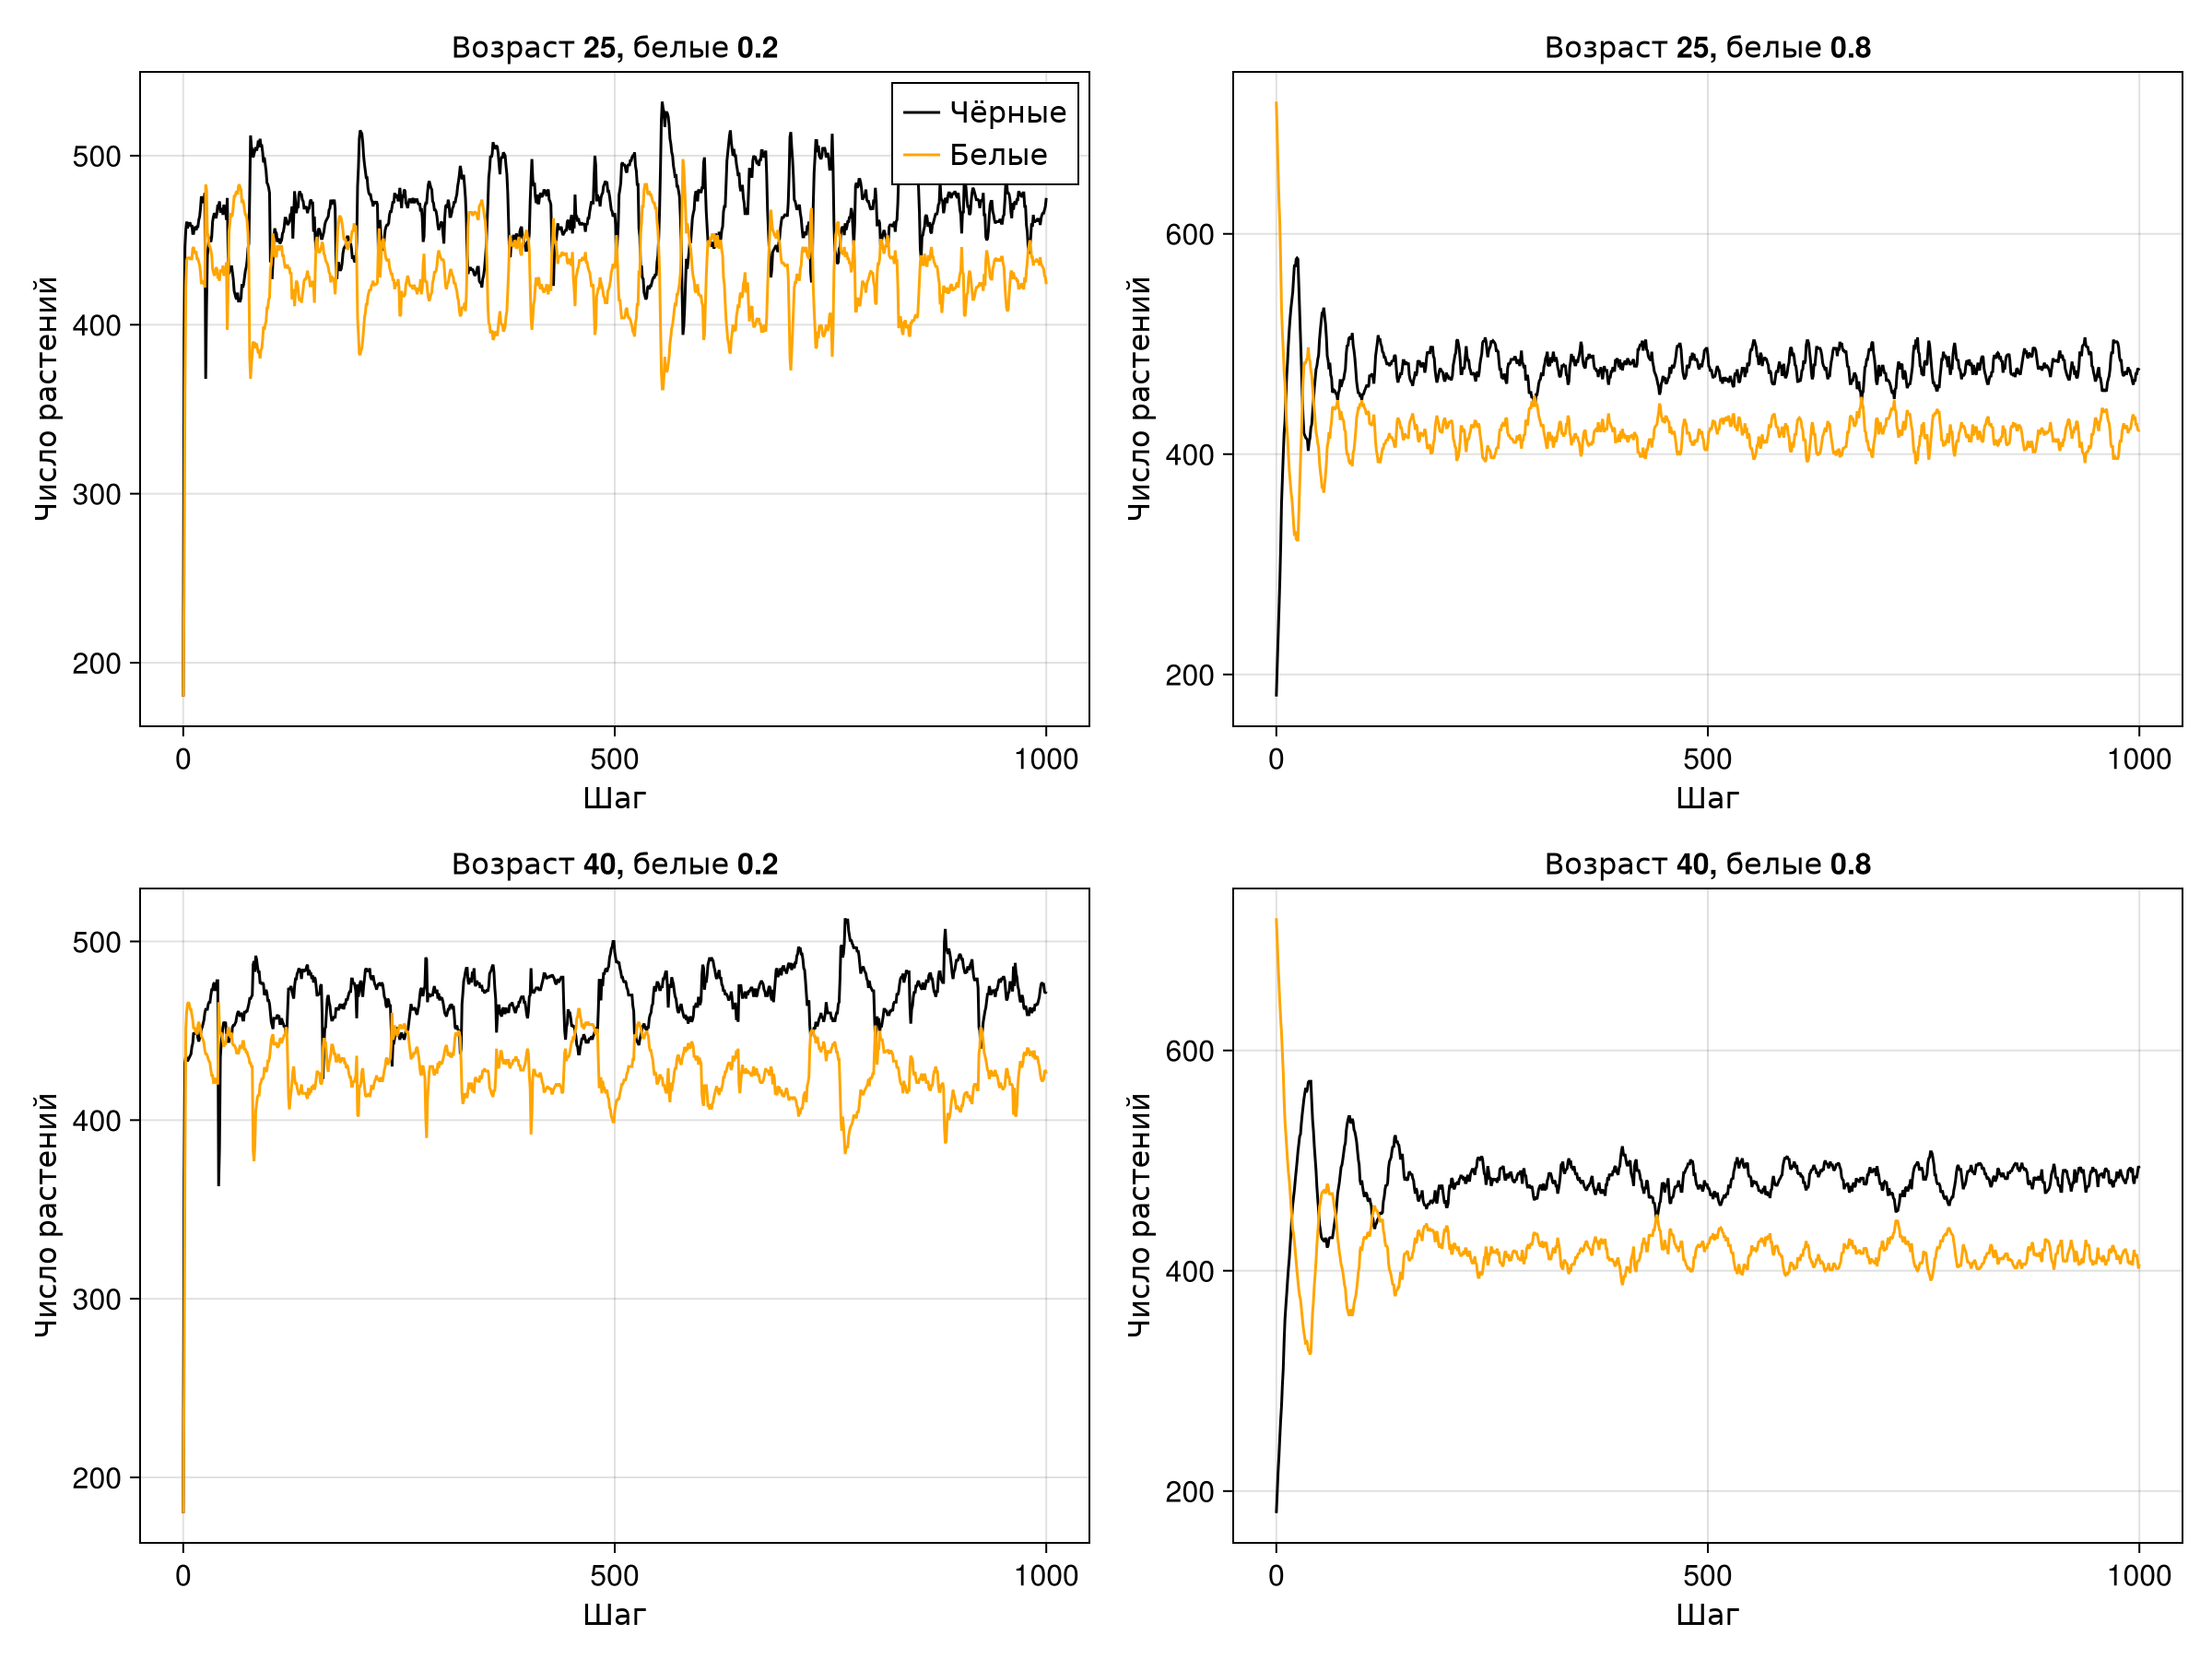

Row,run,max_age,init_white,final_black,final_white,peak_black,peak_white,extinction_step,mean_regulation_error
,Int64,Int64,Float64,Int64,Int64,Int64,Int64,Missing,Float64
1,1,25,0.2,475,424,532,498,missing,1.67895
2,2,25,0.8,478,422,578,720,missing,1.3739
3,3,40,0.2,472,426,513,466,missing,1.19955
4,4,40,0.8,493,406,572,720,missing,1.49961


In [2]:
save_figure(comparison, "daisyworld-count__param", "population-grid.png";
            report_name="parameter-population-comparison.png")
display(comparison)
summary = DataFrame(summary_rows)
CSV.write(scenario_data("daisyworld-count__param", "summary.csv"), summary)
summary